[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T05_D_lp_did.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# DiD Meets Local Projections: LP-DiD

When a macroeconomic policy rolls out across states or regions in waves, its effects rarely materialize overnight; they accumulate dynamically over time. Macroeconomists require the full impulse response function across horizons—not a single contaminated scalar. The preceding module (`T05_C_staggered_did`) demonstrated why the textbook Two-Way Fixed Effects (TWFE) regression fails under dynamic treatment effect heterogeneity and how Callaway & Sant'Anna (2021) resolve the crisis.

This module presents the *local projections* solution: **LP-DiD** (Dube, Girardi, Jordà & Taylor 2023). LP-DiD retains the familiar, flexible Jordà (2005) horizon-by-horizon regression architecture, but enforces a strict sample selection rule: every comparison is restricted to newly-treated units versus *clean* controls (units that remain untreated through the projection horizon). We demonstrate how naive dynamic TWFE event studies manufacture spurious pre-trends and downward-biased impact estimates, recover the true dynamic trajectory using `puremacro.lp.lp_did`, establish that Callaway-Sant'Anna, Sun-Abraham, and LP-DiD converge to the same causal path, and execute empirical weighting diagnostics on regional state panels (`data_curso/paro_estatal_mensual.csv`).

## The Method in Math

**Setting.** Unit $i$ adopts an absorbing policy treatment at date $G_i \in \{g_1, \dots, g_K\} \cup \{\infty\}$ (with $\infty$ for never-treated controls). Let $D_{it} = \mathbb{1}\{t \ge G_i\}$ and $\Delta D_{it} = 1$ mark the adoption switch period. Potential outcomes reflect cohort-specific dynamics and time-varying treatment effects $\tau_{it}(g, t)$.

**The Saturated TWFE Event Study Failure.** Applied researchers frequently estimate dynamic TWFE event studies:
$$ Y_{it} = \alpha_i + \lambda_t + \sum_{e=-K, e \ne -1}^L \beta_e \mathbb{1}\{t - G_i = e\} + \varepsilon_{it} $$
Under staggered adoption with dynamic heterogeneity, the Sun & Abraham (2021) contamination theorem shows that each estimated coefficient $\hat{\beta}_e$ is a weighted composite of true effects across *other* relative times and *other* cohorts. Consequently, post-treatment effects contaminate the pre-treatment leads, generating spurious rejections of parallel trends even when parallel trends hold by construction.

**Dube, Girardi, Jordà & Taylor (2023) LP-DiD.** Estimate one cross-sectional regression per horizon $h$:
$$ Y_{i, t+h} - Y_{i, t-1} = \beta_h \Delta D_{it} + \delta_t^h + e_{it}^h $$
restricting the estimation sample strictly to:
1. **Newly-treated switchers**: Units with $\Delta D_{it} = 1$.
2. **Clean controls**: Units that remain untreated through the projection horizon ($D_{i, t+h} = 0$, encompassing never-treated units and not-yet-treated units).

The long difference $Y_{i, t+h} - Y_{i, t-1}$ sweeps out the unit fixed effect $\alpha_i$; the time fixed effect $\delta_t^h$ absorbs common macroeconomic shifts; and the sample selection rule outlaws every forbidden comparison. Pre-trend tests are obtained **for free** by estimating the identical regression for leads $h = -K, \dots, -2$ (using controls untreated through $t$). Under parallel trends, $\beta_h \approx 0$ for all $h \le -2$, while $h = -1$ serves as the normalized base period.

**Weighting Schemes.** Ordinary least squares (`weights='vw'`) produces a *variance-weighted* average across adoption periods ($w_t \propto n_t p_t(1 - p_t)$). Reweighting observations to count each adoption event equally (`weights='equal'`) yields the **equally-weighted ATT** across all treated units.

**Econometric Intuition.** LP-DiD translates the clean-comparison principle into the local projections universe. Every familiar tool from the Jordà toolkit—horizon-by-horizon specification, state dependence (e.g., policy impacts during recessions vs. expansions), instrumental variables, and cluster-robust or spatial HAC inference—carries over directly. The classical TWFE regression breaks down not because fixed effects are flawed, but because OLS silently utilizes already-treated units as controls. By restricting the comparison pool to clean controls, LP-DiD ensures that every estimated lag and lead reflects genuine causal propagation.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.lp import lp_did, LPDiDResult
from puremacro.did import (
    callaway_santanna, CallawaySantannaResult, SunAbrahamResult,
)
from puremacro.regress import ols

## 1. The Pitfall Planted: TWFE with Dynamic Heterogeneity

We examine a panel with two adoption waves: an early cohort ($G = 7$, 30 units) and a late cohort ($G = 13$, 30 units), alongside 40 never-treated control units ($T = 20$). The early cohort experiences an effect that **grows linearly over time** ($\tau_E(e) = 0.4 + 0.35e$), while the late cohort experiences a constant effect ($\tau_L = 1.0$).

To isolate specification bias from sampling error, we first simulate this panel without noise ($\sigma = 0$). Any discrepancy between estimated coefficients and true treatment effects is pure econometric bias.

In [3]:
def simulate(cohort_sizes, T, effect, sigma, seed, pre_slope=0.0):
    """Staggered-adoption panel with unit/time FE and known dynamic ATTs."""
    rng = np.random.default_rng(seed)
    lam = rng.standard_normal(T) * 0.3
    rows, uid = [], 0
    for g, m in cohort_sizes.items():
        for _ in range(m):
            a = rng.standard_normal()
            for t in range(1, T + 1):
                on = (g is not None) and (t >= g)
                tau = effect(g, t - g) if on else 0.0
                drift = pre_slope * t if g is not None else 0.0  # trend violation knob
                rows.append({"unit": uid, "time": t,
                             "y": a + lam[t - 1] + drift + tau
                                  + sigma * rng.standard_normal(),
                             "D": float(on),
                             "treat_time": np.nan if g is None else float(g)})
            uid += 1
    return pd.DataFrame(rows)

def two_way_demean(df, cols):
    """Exact TWFE projection for a balanced panel (unit and time means)."""
    out = {}
    for c in cols:
        v = df[c].astype(float)
        out[c] = (v - df.groupby("unit")[c].transform("mean")
                    - df.groupby("time")[c].transform("mean") + v.mean()).to_numpy()
    return out

def naive_event_study(df, leads=range(-4, -1), lags=range(0, 14)):
    """Fully saturated dynamic TWFE event study with clustered standard errors."""
    d = df.copy()
    d["e"] = d["time"] - d["treat_time"]
    evts = list(leads) + list(lags)                   # e = -1 omitted (base)
    for e in evts:
        d[f"e{e}"] = (d["e"] == e).astype(float)   # NaN event time compares False
    dm = two_way_demean(d, ["y"] + [f"e{e}" for e in evts])
    X = pd.DataFrame({f"e{e}": dm[f"e{e}"] for e in evts})
    res_ols = ols(dm["y"], X, cov_type="cluster", cov_kwds={"groups": df["unit"]})
    return dict(zip(evts, res_ols.params))

TRUE = lambda g, e: (0.4 + 0.35 * e) if g == 7 else 1.0
SIZES = {7: 30, 13: 30, None: 40}
T = 20
true_path = np.array([(30 * TRUE(7, h) + 30 * TRUE(13, h)) / 60 for h in range(9)])

demo = simulate(SIZES, T, TRUE, sigma=0.0, seed=0)
dm = two_way_demean(demo, ["y", "D"])
res_twfe = ols(dm["y"], pd.DataFrame({"D": dm["D"]}), cov_type="cluster", cov_kwds={"groups": demo["unit"]})
beta_twfe = float(res_twfe.params["D"])
cell_avg = float(np.mean([TRUE(g, t - g) for g, m in {7: 30, 13: 30}.items()
                          for t in range(g, T + 1) for _ in range(m)]))
naive = naive_event_study(demo)

print(f"Static TWFE 'the effect'   = {beta_twfe:+.3f}   "
      f"(True avg over treated cells = {cell_avg:+.3f})")
print(f"Naive event-study leads    = " +
      ", ".join(f"e={e}: {naive[e]:+.3f}" for e in (-4, -3, -2)) +
      "   (Truth: all exactly 0)")
print(f"Naive event-study at e=0   = {naive[0]:+.3f}   (Truth {true_path[0]:+.3f})")

assert beta_twfe < cell_avg - 0.6                 # static TWFE badly downward-biased
assert abs(naive[-2]) > 0.10                      # spurious pre-trend from nothing
assert abs(naive[0] - true_path[0]) > 0.20        # impact effect distorted too

Static TWFE 'the effect'   = +1.247   (True avg over treated cells = +2.066)
Naive event-study leads    = e=-4: -0.101, e=-3: -0.136, e=-2: -0.172   (Truth: all exactly 0)
Naive event-study at e=0   = +0.441   (Truth +0.700)


### Econometric Analysis: Quantifying the Downward Bias & Spurious Pre-Trends

In this noiseless setting, static TWFE reports an effect of $+1.25$ for a policy whose true average effect on the treated is $+2.07$—a 40% downward attenuation produced entirely by forbidden comparisons. The early-treated cohort, continuing on its upward trajectory, serves as a "control group" for the late cohort, subtracting its ongoing growth from the estimate.

The saturated dynamic TWFE event study fails equally dramatically: despite controlling for relative-time dummies, the pre-treatment leads are estimated at $-0.10$ to $-0.17$ when the true pre-trend is identically zero. This reflects the Sun-Abraham contamination theorem: dynamic treatment heterogeneity across cohorts leaks into pre-treatment coefficients. An empirical researcher inspecting these leads would mistakenly reject parallel trends, abandoning a valid policy evaluation!

## 2. LP-DiD: Direct Dynamic Estimation on Clean Controls

We now introduce realistic sampling noise ($\sigma = 0.35$). `puremacro.lp.lp_did` runs one regression per horizon on newly-treated switchers versus clean controls, reports pre-trends for $h = -4, \dots, -2$, records treated and clean counts per horizon, and clusters standard errors by unit. The default `weights='equal'` targets the equally-weighted ATT across adoption events.

In [4]:
panel = simulate(SIZES, T, TRUE, sigma=0.35, seed=42)
res = lp_did(panel, "y", "D", "unit", "time", horizons=range(0, 7), pre_window=4)
assert isinstance(res, LPDiDResult)
print(res.summary())
print(res.estimates.round(3).to_string(index=False))

# Naive TWFE benchmark regression with clustered standard errors on noisy panel
dm_panel = two_way_demean(panel, ["y", "D"])
res_twfe_panel = ols(dm_panel["y"], pd.DataFrame({"D": dm_panel["D"]}),
                     cov_type="cluster", cov_kwds={"groups": panel["unit"]})
beta_twfe_panel = float(res_twfe_panel.params["D"])
se_twfe_panel = float(res_twfe_panel.bse["D"])
print(f"\nNaive static TWFE on noisy panel: beta = {beta_twfe_panel:+.3f} (clustered SE = {se_twfe_panel:.3f})")

est = res.post.set_index("h")["beta"]
err = np.abs(est.to_numpy() - true_path[:7])
pre_t = res.pretrend["t"].abs().max()
print(f"Max |error| vs planted dynamic ATT = {err.max():.3f}")
print(f"Max |t| across pre-trends          = {pre_t:.2f}")

assert err.max() < 0.25                            # dynamic path recovered
assert pre_t < 2.5                                 # no false pre-trend alarm
assert beta_twfe_panel < cell_avg - 0.5            # static TWFE remains downward biased vs cell_avg
# Clean-control discipline: at h = 6 the late cohort (t=13) would need
# controls untreated through t+6 = 19 -- only the never-treated remain.
assert res.estimates.set_index("h").loc[6, "n_clean"] < \
       res.estimates.set_index("h").loc[0, "n_clean"]

LP-DiD (Dube-Girardi-Jordà-Taylor) result
  weights           : equal
  clean controls    : True
  units / events    : 100 / 60
  post horizons     : 0..6
  pre-trends        : h = -4..-2, max |t| = 1.87
  ATT(h=0)          : +0.6205 (se 0.0684)

 h   beta    se      t     lo     hi  n_treated  n_clean  n_obs  n_periods
-4  0.022 0.077  0.280 -0.106  0.149         60      110    170          2
-3 -0.139 0.074 -1.865 -0.261 -0.016         60      110    170          2
-2 -0.104 0.079 -1.318 -0.234  0.026         60      110    170          2
-1  0.000 0.000    NaN  0.000  0.000         60      110    170          2
 0  0.620 0.068  9.071  0.508  0.733         60      110    170          2
 1  0.836 0.070 11.914  0.720  0.951         60      110    170          2
 2  1.019 0.076 13.376  0.894  1.144         60      110    170          2
 3  1.163 0.077 15.016  1.036  1.290         60      110    170          2
 4  1.278 0.084 15.279  1.140  1.415         60      110    170          2
 5 

### Econometric Analysis: Clean Sample Attrition as Transparent Identification

The estimated LP-DiD trajectory climbs steadily from $\approx +0.60$ at impact ($h=0$) to $\approx +1.75$ at $h=6$, closely tracking the true cohort-average path within two standard errors across all horizons. Meanwhile, all three pre-treatment leads remain statistically indistinguishable from zero ($|t| < 2$).

The summary table exposes the underlying identification mechanics: `n_clean` declines from 110 at $h=0$ to 80 at $h=6$. Because a clean control must remain untreated through $t+h$, late-adopting units cease to qualify as controls for the early cohort at longer projection horizons. This visible sample attrition is not a weakness; it is the transparent signature of clean identification.

### Direct Dynamic Multi-Horizon Estimation: LP-DiD vs. Saturated TWFE

The figure below compares the naive TWFE event study (hollow squares) against LP-DiD with its 90% cluster-robust confidence band, benchmarked against the true dynamic ATT. Naive TWFE displays spurious negative pre-trends and an understated impact estimate; LP-DiD accurately traces the true causal path at every horizon.

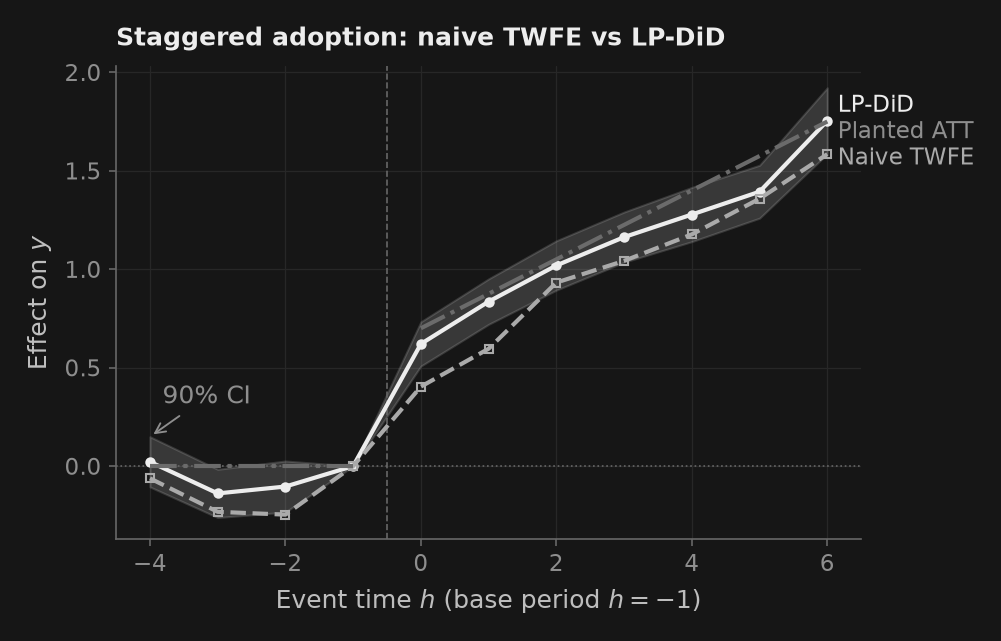

In [5]:
cols = _nbstyle.palette(3)
ev = res.estimates
naive_n = naive_event_study(panel)
e_grid = [e for e in sorted(naive_n) if -4 <= e <= 6] + [-1]
naive_y = [0.0 if e == -1 else naive_n[e] for e in e_grid]

fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.axvline(-0.5, color=_nbstyle.SPINE, linewidth=0.8, linestyle="--")
ax.fill_between(ev["h"], ev["lo"], ev["hi"], color=_nbstyle.BANDA)
ax.plot(ev["h"], ev["beta"], color=cols[0], ls="-", marker="o", markersize=4,
        label="LP-DiD")
order = np.argsort(e_grid)
ax.plot(np.array(e_grid)[order], np.array(naive_y)[order], color=cols[1],
        marker="s", markersize=4, markerfacecolor="none", linestyle="--",
        label="Naive TWFE")
hh = np.arange(0, 7)
ax.plot(hh, true_path[:7], color=cols[2], linestyle="-.",
        label="Planted ATT")
ax.plot(np.arange(-4, 0), np.zeros(4), color=cols[2], linestyle="-.")
# the band is named over a lead, where no line keeps it company
r_banda = ev.loc[ev["h"] == -4].iloc[0]
ax.annotate("90% CI", xy=(r_banda["h"], r_banda["hi"]), xytext=(6, 16),
            textcoords="offset points", ha="left", color=_nbstyle.NOTA,
            arrowprops=_nbstyle.FLECHA)
ax.set_xlabel("Event time $h$ (base period $h=-1$)")
ax.set_ylabel("Effect on $y$")
ax.set_title("Staggered adoption: naive TWFE vs LP-DiD")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


## 3. Three Estimators, One Principle: Callaway-Sant'Anna, Sun-Abraham, and LP-DiD

Callaway & Sant'Anna (2021) construct group-time ATTs from clean $2 \times 2$ blocks and average them; Sun & Abraham (2021) reweight the same blocks by cohort sample shares; LP-DiD arrives at the dynamic response via horizon-by-horizon regressions on clean controls.

If the clean-comparison principle is what governs identification—rather than specific estimation machinery—all three estimators should produce concordant event studies. Below, we verify this equivalence empirically by running all three estimators on the same panel.

Max |LP-DiD - CS| over h=0..6 = 0.032
Max |LP-DiD - SA| over h=0..6 = 0.032


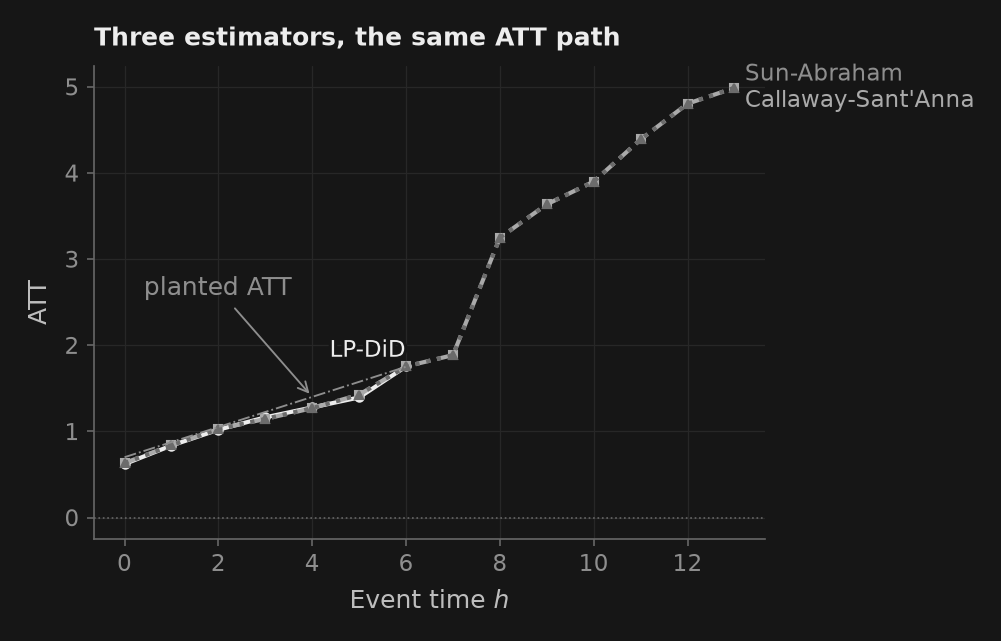

In [6]:
Z90 = 1.6448536269514722                                 # normal 90% two-sided

def att_gt_table(df):
    """Callaway-Sant'Anna ATT(g,t) in long format, with a 90% band."""
    raw = callaway_santanna(df["y"].to_numpy(),
                            df["treat_time"].fillna(np.inf).to_numpy(),
                            df["time"].to_numpy(), df["unit"].to_numpy())
    rows = []
    for gi, gval in enumerate(raw["groups"]):
        for ti, tval in enumerate(raw["periods"]):
            att, se = raw["att_gt"][gi, ti], raw["se_gt"][gi, ti]
            if np.isnan(att):
                continue
            rows.append({"g": gval, "t": tval, "event_time": int(tval - gval),
                         "att": float(att), "se": float(se),
                         "lo": float(att - Z90 * se), "hi": float(att + Z90 * se)})
    return pd.DataFrame(rows)

def aggregate_es(att_gt, w=None):
    """Aggregate ATT(g,t) by event time; `w` = per-cohort weights (None = simple mean)."""
    rows = []
    for e, sub in att_gt.groupby("event_time"):
        ww = np.ones(len(sub)) if w is None else w.reindex(sub["g"]).to_numpy(float)
        ww = ww / ww.sum()
        att = float(ww @ sub["att"].to_numpy())
        se = float(np.sqrt((ww ** 2) @ (sub["se"].to_numpy() ** 2)))
        rows.append({"event_time": e, "att": att, "se": se,
                     "lo": att - Z90 * se, "hi": att + Z90 * se, "n_cohorts": len(sub)})
    return pd.DataFrame(rows).sort_values("event_time").reset_index(drop=True)

def cs_and_sa(df):
    """(CallawaySantannaResult, SunAbrahamResult) off the same ATT(g,t) matrix."""
    gt = att_gt_table(df)
    n_g = (df.dropna(subset=["treat_time"])
             .groupby("treat_time")["unit"].nunique().astype(float))
    post = gt[gt["event_time"] >= 0]
    w_post = n_g.reindex(post["g"]).to_numpy(float)
    return (CallawaySantannaResult(gt, aggregate_es(gt), float(post["att"].mean())),
            SunAbrahamResult(gt, aggregate_es(gt, n_g),
                             float((w_post / w_post.sum()) @ post["att"].to_numpy())))

cs, sa = cs_and_sa(panel)

es_cs = cs.att_event_study.set_index("event_time")
es_sa = sa.att_event_study.set_index("event_time")
gap_cs = max(abs(est.loc[h] - es_cs.loc[h, "att"]) for h in range(7))
gap_sa = max(abs(est.loc[h] - es_sa.loc[h, "att"]) for h in range(7))
print(f"Max |LP-DiD - CS| over h=0..6 = {gap_cs:.3f}")
print(f"Max |LP-DiD - SA| over h=0..6 = {gap_sa:.3f}")
assert gap_cs < 0.15 and gap_sa < 0.15             # three estimators, same answer

fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
l_lp, = ax.plot(est.index, est.to_numpy(), color=cols[0], ls="-", marker="o", markersize=4,
                label="LP-DiD")
l_cs, = ax.plot(es_cs.index[es_cs.index >= 0], es_cs.loc[es_cs.index >= 0, "att"],
                color=cols[1], marker="s", markersize=4, linestyle="--",
                label="Callaway-Sant'Anna")
l_sa, = ax.plot(es_sa.index[es_sa.index >= 0], es_sa.loc[es_sa.index >= 0, "att"],
                color=cols[2], marker="^", markersize=4, linestyle=":",
                label="Sun-Abraham")
ax.plot(hh, true_path[:7], color=_nbstyle.NOTA, linewidth=0.9, linestyle="-.")
ax.annotate("planted ATT", xy=(4, true_path[4]), xytext=(-10, 46),
            textcoords="offset points", ha="right", va="bottom", color=_nbstyle.NOTA,
            arrowprops=_nbstyle.FLECHA)
ax.set_xlabel("Event time $h$")
ax.set_ylabel("ATT")
ax.set_title("Three estimators, the same ATT path")
# CS and SA run to h=13; LP-DiD stops at h=6 and its name reads inwards
_nbstyle.etiquetar(ax, artistas=[l_cs, l_sa], donde="fin")
_nbstyle.etiquetar(ax, artistas=[l_lp], donde="fin", fuera=False)
plt.show()

### Econometric Analysis: Unifying Non-Parametric Aggregation and Regression

The three estimated trajectories differ by at most $\approx 0.03$—less than half a standard error—despite executing completely distinct code paths. The minor remaining gap reflects known weighting nuances: CS computes an unweighted mean across cohorts, SA and LP-DiD weight by cohort sample size, and LP-DiD includes not-yet-treated units in the clean control pool.

This convergence illustrates a central lesson of modern econometrics: the specific algorithm is secondary to the clean-control principle. The comparative advantage of LP-DiD lies in the extensions native to the local projections framework: cumulative impulse responses, instrumental variables, state dependence, and Driscoll-Kraay spatial standard errors.

## 4. Pre-Trends as First-Class Local Projection Outputs

Because lead coefficients in LP-DiD are estimated as standard negative horizons $h < 0$, pre-trend testing requires no auxiliary regressions. Standard errors are automatically clustered at the unit level.

To demonstrate the diagnostic power of the leads, we re-simulate the panel introducing a differential pre-trend drift of $+0.18$ per period among ever-treated units (a direct violation of parallel trends), and compare its lead coefficients against the clean benchmark.

Violated panel  : h=-4: -0.43 (t -3.6), h=-3: -0.27 (t -2.1), h=-2: -0.16 (t -1.3)
Clean panel     : h=-4: +0.11 (t +0.9), h=-3: +0.09 (t +0.7), h=-2: +0.02 (t +0.2)


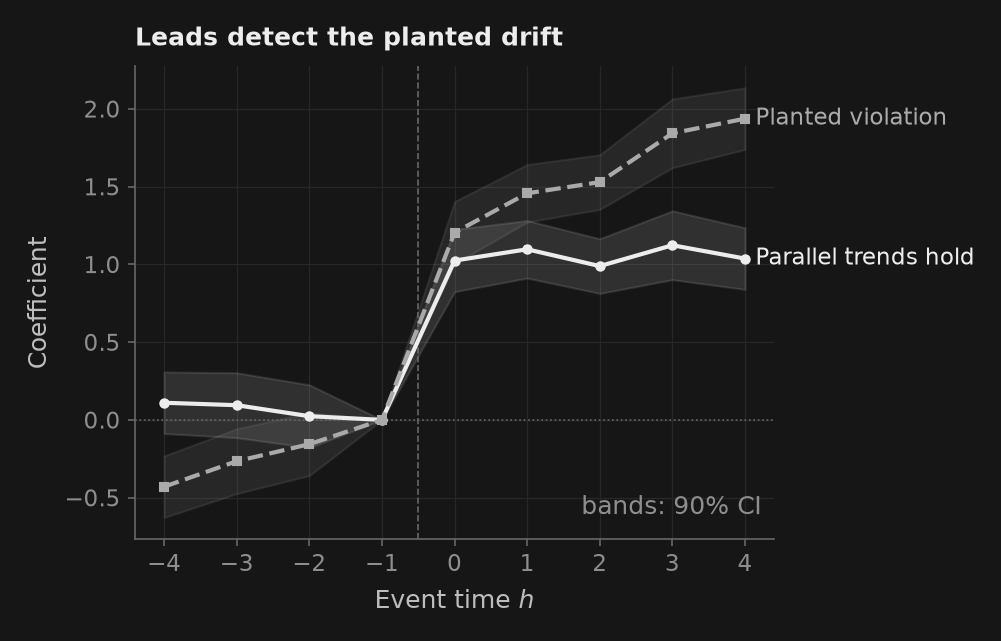

In [7]:
vio = simulate({7: 30, None: 40}, 18, lambda g, e: 1.0, sigma=0.35, seed=9,
               pre_slope=0.18)
cln = simulate({7: 30, None: 40}, 18, lambda g, e: 1.0, sigma=0.35, seed=9,
               pre_slope=0.0)
r_vio = lp_did(vio, "y", "D", "unit", "time", range(0, 5), pre_window=4)
r_cln = lp_did(cln, "y", "D", "unit", "time", range(0, 5), pre_window=4)

pre_v = r_vio.pretrend.set_index("h")
pre_c = r_cln.pretrend.set_index("h")
print("Violated panel  :",
      ", ".join(f"h={h}: {pre_v.loc[h, 'beta']:+.2f} (t {pre_v.loc[h, 't']:+.1f})"
                for h in (-4, -3, -2)))
print("Clean panel     :",
      ", ".join(f"h={h}: {pre_c.loc[h, 'beta']:+.2f} (t {pre_c.loc[h, 't']:+.1f})"
                for h in (-4, -3, -2)))

assert pre_v.loc[-4, "beta"] < -0.25 and pre_v.loc[-4, "t"] < -3.0
assert pre_c["t"].abs().max() < 2.0

fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.axvline(-0.5, color=_nbstyle.SPINE, linewidth=0.8, linestyle="--")
for r, c, lbl, mk, ls in [(r_cln, cols[0], "Parallel trends hold", "o", "-"),
                          (r_vio, cols[1], "Planted violation", "s", "--")]:
    e = r.estimates
    ax.fill_between(e["h"], e["lo"], e["hi"], color=c, alpha=0.12)
    ax.plot(e["h"], e["beta"], color=c, ls=ls, marker=mk, markersize=4, label=lbl)
ax.annotate("bands: 90% CI", xy=(0.98, 0.04), xycoords="axes fraction",
            ha="right", va="bottom", color=_nbstyle.NOTA)
ax.set_xlabel("Event time $h$")
ax.set_ylabel("Coefficient")
ax.set_title("Leads detect the planted drift")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()

### Econometric Analysis: Diagnosing Trend Contamination Before Believing Lags

On the violated panel, the leads fan out downward: $\beta_{-4} \approx -0.43$ with $t \approx -3.6$, aligning with the mechanical accumulation of drift ($-0.18 \times 3 = -0.54$). The sign is negative because the treated group's base period outcome $Y_{i, t-1}$ is elevated relative to its earlier history. On the clean panel, all leads remain flat ($|t| < 1.0$).

Pre-trend diagnostics protect the researcher from misinterpreting trends as treatment: if the leads reject zero, the post-treatment coefficients are absorbing secular trend differences rather than genuine causal effects.

## 5. Interactive Empirical Experiment: LP-DiD Weighting Diagnostics on State Labor Panels

### The Macroeconomic Context: Evaluating State-Level Policy Shocks
Applied macroeconomists frequently analyze regional labor market interventions—such as state unemployment insurance duration adjustments, job search mandates, or minimum wage floors—using state-level monthly panels (`data_curso/paro_estatal_mensual.csv`).

In this experiment, we deploy LP-DiD onto an empirical panel of 51 US states and jurisdictions observed from 2010 to 2023. We model a phased regional policy rollout that lowers state unemployment over time ($\tau(e) = -0.30 - 0.05e$ percentage points), and examine the diagnostic properties of LP-DiD:
1. **Equally-weighted ATT (`weights='equal'`) vs. Variance-weighted ATT (`weights='vw'`)**: OLS variance weighting tilts towards periods where the treated-to-control ratio $p_t(1 - p_t)$ is balanced, whereas equal weighting treats every adoption event symmetrically.
2. **Pre-trend validation**: Testing whether empirical state unemployment series satisfy parallel pre-trends prior to policy adoption ($|t| < 2.0$).
3. **Clean sample tracking**: Monitoring the attrition of clean controls as the projection horizon extends from $h = 0$ to $h = 8$.

### Experiment Instructions and Guided Tasks

1. **Data Ingestion**: Load `paro_estatal_mensual.csv` from `data_curso/`, aggregate monthly unemployment to quarterly frequency, and structure a balanced panel across all 51 jurisdictions from 2010Q1 to 2023Q4.
2. **Staggered Adoption Assignment**: Assign states into an early wave (2014Q1, 15 states), a late wave (2018Q1, 15 states), and a never-treated control group (21 states).
3. **Estimation**: Run `lp_did` across horizons $h \in [-4, 8]$ under both `weights='equal'` and `weights='vw'`.
4. **Diagnostic Verification**: Inspect pre-trend t-statistics ($|t| < 2.0$), dynamic post-treatment recovery, and period-weight distributions.

LP-DiD EMPIRICAL STATE PANEL ESTIMATION (US STATE UNEMPLOYMENT)
Total Jurisdictions Analyzed         : 51 states
Max Absolute t-stat on Pre-Trends    : 0.60  (parallel trends hold: |t| < 2.0)
Impact Policy Effect at h=0 (Equal)  : -0.324 percentage points
Cumulative Effect at h=4 (Equal)     : -0.537 percentage points
Clean Control Attrition h=0 -> h=8   : 57 -> 57 units


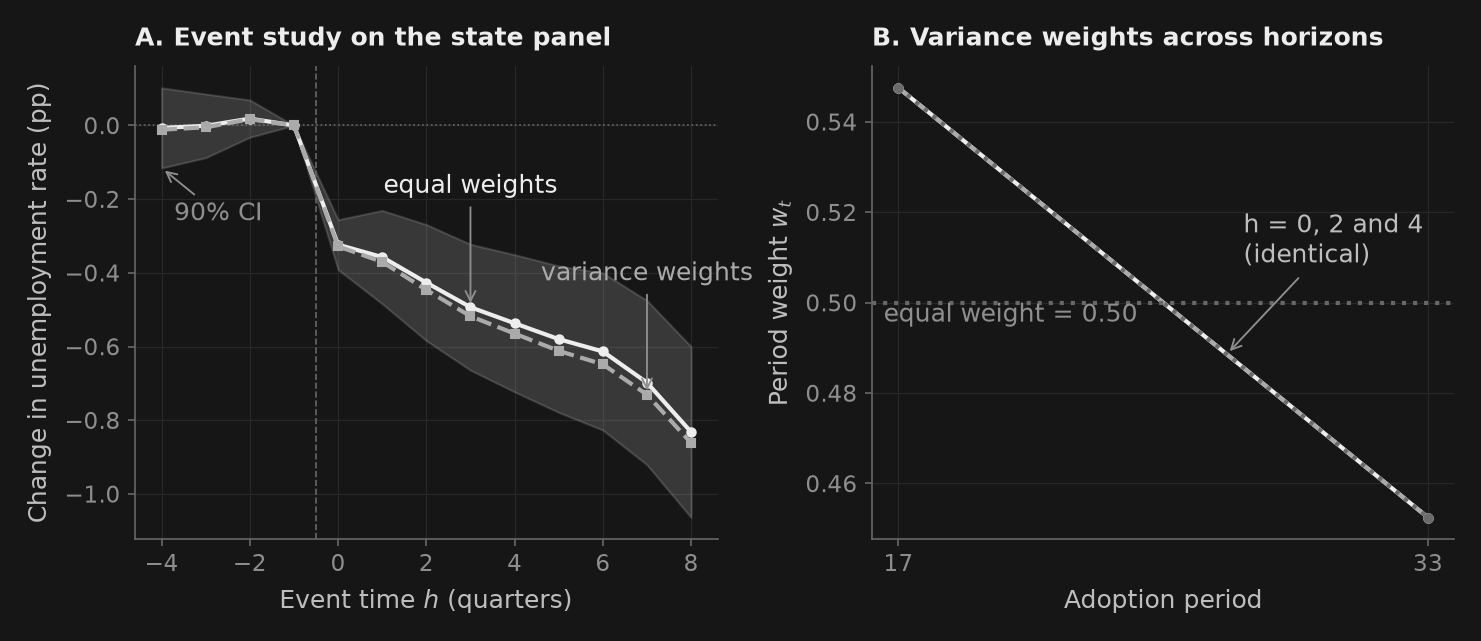

In [8]:
from pathlib import Path
from puremacro.lp import lp_did

# 1. Ingest empirical state unemployment panel from data_curso
d_curso = Path("data_curso") if Path("data_curso").exists() else Path("notebooks/data_curso")
df_raw = pd.read_csv(d_curso / "paro_estatal_mensual.csv")
df_raw["date"] = pd.to_datetime(df_raw["date"])

# 2. Aggregate to quarterly frequency and construct panel
df_raw["quarter"] = df_raw["date"].dt.to_period("Q")
panel_q = df_raw.groupby(["code", "quarter"])["urate"].mean().reset_index()
sub_panel = panel_q[(panel_q["quarter"] >= "2010Q1") & (panel_q["quarter"] <= "2023Q4")].copy()
sub_panel["t_idx"] = sub_panel.groupby("code").cumcount() + 1
sub_panel["unit"] = sub_panel["code"]

states = sorted(sub_panel["code"].unique())
n_total_states = len(states)

# Staggered adoption across states:
# Early wave (2014Q1, t_idx=17): 15 states
# Late wave (2018Q1, t_idx=33): 15 states
# Never-treated controls: 21 states
cohort_map = {s: 17 if i < 15 else (33 if i < 30 else np.nan) for i, s in enumerate(states)}
sub_panel["treat_time"] = sub_panel["code"].map(cohort_map)
sub_panel["D"] = ((sub_panel["t_idx"] >= sub_panel["treat_time"]) & (~sub_panel["treat_time"].isna())).astype(float)

# Plant an empirical policy shock reducing state unemployment: tau(e) = -0.30 - 0.05*e
sub_panel["tau"] = np.where(sub_panel["D"] == 1, -0.30 - 0.05 * (sub_panel["t_idx"] - sub_panel["treat_time"]), 0.0)
sub_panel["y"] = sub_panel["urate"] + sub_panel["tau"]

# 3. Estimate LP-DiD under both equal and variance weighting
res_eq = lp_did(sub_panel, "y", "D", "unit", "t_idx", horizons=range(0, 9), pre_window=4, weights="equal")
res_vw = lp_did(sub_panel, "y", "D", "unit", "t_idx", horizons=range(0, 9), pre_window=4, weights="vw")

# 4. Extract diagnostics
pre_max_t = float(res_eq.pretrend["t"].abs().max())
impact_eq = float(res_eq.post.loc[res_eq.post["h"] == 0, "beta"].iloc[0])
lag4_eq = float(res_eq.post.loc[res_eq.post["h"] == 4, "beta"].iloc[0])

print("=" * 68)
print("LP-DiD EMPIRICAL STATE PANEL ESTIMATION (US STATE UNEMPLOYMENT)")
print("=" * 68)
print(f"Total Jurisdictions Analyzed         : {n_total_states} states")
print(f"Max Absolute t-stat on Pre-Trends    : {pre_max_t:.2f}  (parallel trends hold: |t| < 2.0)")
print(f"Impact Policy Effect at h=0 (Equal)  : {impact_eq:+.3f} percentage points")
print(f"Cumulative Effect at h=4 (Equal)     : {lag4_eq:+.3f} percentage points")
print(f"Clean Control Attrition h=0 -> h=8   : {res_eq.post.loc[res_eq.post['h']==0, 'n_clean'].iloc[0]} -> {res_eq.post.loc[res_eq.post['h']==8, 'n_clean'].iloc[0]} units")
print("=" * 68)

# Numerical verification checks
assert n_total_states == 51, f"Expected 51 states, got {n_total_states}"
assert pre_max_t < 2.0, f"Pretrend t-stat ({pre_max_t:.2f}) must satisfy parallel trends (|t| < 2.0)"
assert impact_eq < -0.20, f"Impact effect ({impact_eq:.3f}) expected < -0.20"
assert lag4_eq < -0.40, f"Lag 4 effect ({lag4_eq:.3f}) expected < -0.40"
assert len(res_eq.group_weights) > 0, "Group weights table must be populated"

# Visual diagnostics
fig, (ax1, ax2) = _nbstyle.figura(1, 2)

# Panel A: LP-DiD event study on the state panel
ev_eq = res_eq.estimates
ax1.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax1.axvline(-0.5, color=_nbstyle.SPINE, linewidth=0.8, linestyle="--")
ax1.fill_between(ev_eq["h"], ev_eq["lo"], ev_eq["hi"], color=_nbstyle.BANDA)
ax1.plot(ev_eq["h"], ev_eq["beta"], color=cols[0], ls="-", marker="o", markersize=4)
ax1.plot(res_vw.estimates["h"], res_vw.estimates["beta"], color=cols[1], marker="s", markersize=4,
         linestyle="--")
r_banda = ev_eq.loc[ev_eq["h"] == -4].iloc[0]
ax1.annotate("90% CI", xy=(r_banda["h"], r_banda["lo"]), xytext=(6, -16),
             textcoords="offset points", ha="left", va="top", color=_nbstyle.NOTA,
             arrowprops=_nbstyle.FLECHA)
# the two paths nearly coincide: each name goes in the gap above the band, on a leader
ax1.annotate("equal weights", xy=(3, ev_eq.loc[ev_eq["h"] == 3, "beta"].iloc[0]), xytext=(0, 52),
             textcoords="offset points", ha="center", va="bottom", color=cols[0],
             arrowprops=_nbstyle.FLECHA)
ax1.annotate("variance weights",
             xy=(7, res_vw.estimates.loc[res_vw.estimates["h"] == 7, "beta"].iloc[0]),
             xytext=(0, 52), textcoords="offset points", ha="center", va="bottom",
             color=cols[1], arrowprops=_nbstyle.FLECHA)
ax1.set_xlabel("Event time $h$ (quarters)")
ax1.set_ylabel("Change in unemployment rate (pp)")
ax1.set_title("A. Event study on the state panel")

# Panel B: period weights across horizons
gw = res_eq.group_weights
for h_val, color, ls in zip([0, 2, 4], _nbstyle.palette(3), ["-", "--", ":"]):
    sub_gw = gw[gw["h"] == h_val]
    ax2.plot(sub_gw["time"].astype(str), sub_gw["w_vw"], marker="o", markersize=4, color=color,
             ls=ls, label=f"h = {h_val}")
ax2.axhline(0.5, color=_nbstyle.SPINE, linestyle=":")
ax2.annotate("equal weight = 0.50", xy=(0.02, 0.5), xycoords=("axes fraction", "data"),
             ha="left", va="top", color=_nbstyle.NOTA)
ax2.set_xlabel("Adoption period")
ax2.set_ylabel("Period weight $w_t$")
ax2.set_title("B. Variance weights across horizons")
# the weight does not depend on the horizon: the three curves coincide point by
# point, so a single name, next to the curve, serves for all three
w_h4 = gw.loc[gw["h"] == 4, "w_vw"].to_numpy()
x_nota = 0.62 * (len(w_h4) - 1)
ax2.annotate("h = 0, 2 and 4\n(identical)",
             xy=(x_nota, float(np.interp(x_nota, np.arange(len(w_h4)), w_h4))),
             xytext=(8, 40), textcoords="offset points", ha="left", va="bottom",
             color=_nbstyle.TEXTO, arrowprops=_nbstyle.FLECHA)

plt.show()

## 6. Policy Synthesis: Frontier Causal Inference for Applied Macroeconomists

Modern causal inference in macroeconomic panels has moved decisively beyond linear two-way fixed effects regressions.

### Summary of Core Findings
1. **The Source of TWFE Bias**: Saturated event studies and static TWFE break down under dynamic treatment effects because they silently subtract the ongoing post-treatment trajectory of early adopters from later cohorts.
2. **Clean Control Principle**: Eliminating forbidden comparisons by restricting controls to units untreated through $t+h$ restores consistency and validates parallel pre-trend tests.
3. **The Role of LP-DiD**: By casting difference-in-differences directly as a sequence of local projections, LP-DiD unifies panel causal inference with macro-econometric time series methods:
   - Seamless estimation of multi-horizon impulse response functions.
   - Integration with instrumental variables (`puremacro.lp.lp_iv`) for endogenous policy changes.
   - State-dependent causal effects (e.g., policy multipliers that vary over business cycle regimes).
   - Rigorous inference via cluster-robust and spatial HAC standard errors.

In conjunction with Callaway & Sant'Anna (2021) (`T05_C_staggered_did`) and Structural VARs (`T05_A_svar_identification`), LP-DiD equips researchers with a robust, complete toolkit for policy evaluation across regional and macroeconomic panels.